# Step 3.3

Visualise Variance Partitioning

In [1]:
import random
import os
import pandas
import datetime

from useful import rexp, format_timedelta, logit, logistic, rnorm
from numpy import array, log, exp, mean, std, linspace
from scipy import stats

import new_artist as artist

import plots


from load_data import *
import model
import read_data

from scipy import stats

/home/shubin/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shubin/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


# Compute the quantiles of responses, using posterior Samples

In [2]:
SL = DictOfUsedFish()

In [3]:
EN = 5
VP = pandas.read_csv(f'internal_results/variance_partition_{EN}_avg.csv')
VP

,total,depth,dts,td,dfb,geo,year,turb,oxyg,salt,...,turb_14,salt_15,temp_15,oxyg_15,turb_15,salt_16,temp_16,oxyg_16,turb_16,Species
0,1.777881,0.000807,0.142468,0.000001,0.193480,0.851368,0.002897,0.029311,0.032398,0.035769,...,0.020802,0.040688,0.431588,0.030078,0.038344,0.038070,0.459851,0.025284,0.032450,Atlantic herring
1,1.869149,0.001896,0.003778,0.000261,0.032471,0.794341,0.064647,0.170433,0.066902,0.010267,...,0.127250,0.011625,0.570807,0.061444,0.227029,0.011085,0.639033,0.049710,0.190681,Atlantic herring
2,1.091939,0.008363,0.000005,0.094345,0.105712,0.242717,0.185431,0.219385,0.041310,0.002617,...,0.151749,0.003112,0.050602,0.040791,0.295379,0.002857,0.054696,0.038444,0.250225,Atlantic herring
3,1.162056,0.011503,0.034472,0.000338,0.074434,0.256409,0.311246,0.166859,0.038339,0.012911,...,0.126159,0.013920,0.197031,0.040184,0.202885,0.013744,0.193437,0.040244,0.178936,Atlantic herring
4,2.091375,0.013955,0.000764,0.016371,0.000189,0.604747,0.572840,0.173232,0.160903,0.004006,...,0.111480,0.004367,0.345449,0.123108,0.250221,0.004228,0.350739,0.078474,0.194355,Atlantic herring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,11.512564,0.000733,1.328690,0.280062,6.503709,0.000034,0.120882,3.202653,0.008662,0.011890,...,2.238642,0.012682,0.001002,0.010918,3.826962,0.012538,0.001575,0.010831,3.411803,Zander
44996,3.951763,0.204199,0.604333,0.016647,2.090161,0.000032,0.025823,0.799233,0.026938,0.954879,...,0.580794,0.961014,0.243752,0.038460,0.940887,0.994651,0.233803,0.044225,0.843750,Zander
44997,3.325409,0.008620,0.003469,0.539257,0.079236,0.005914,0.009718,2.726814,0.225227,0.154452,...,1.896958,0.173671,0.003501,0.243562,3.246519,0.165396,0.004470,0.219206,2.917242,Zander
44998,6.598553,0.000315,0.056831,0.004316,0.882598,0.000150,0.000184,1.736306,0.003555,3.709207,...,1.211469,3.713372,0.318804,0.003846,1.952340,3.638850,0.364411,0.003440,1.806748,Zander


# Responce Plots

In [4]:
CLUSTERS = [
 'her',
 'spr',
 'stb',],[
    'wee',
 'amakr',
 'sard',
 'hake',
 'gurnard',
 'mullet',
 'shark',
 'plaice',
 'haddock',],[
 'ach',
 'makr',
 'whit',
 'tgoby',
 'dab',
 'garf',
 'bgoby',
 'fangtooth',
 'wrasse',
 'hook',],[
 'flo',
 'pom',
 'pla',
 'eeel',
 'rgoby',],[
 'cod',
 'rock',],[
 'lumpf',
 'rout',
 'turbot',],[
 'stb9',
 'sal',
 'eel',],[
 'pip',
 'snake',],[
 'snail',],[
 'smelt',
 'eelpout',
 'lamprey',
 'lse',
 'trout',
 'scul',
 'zand']

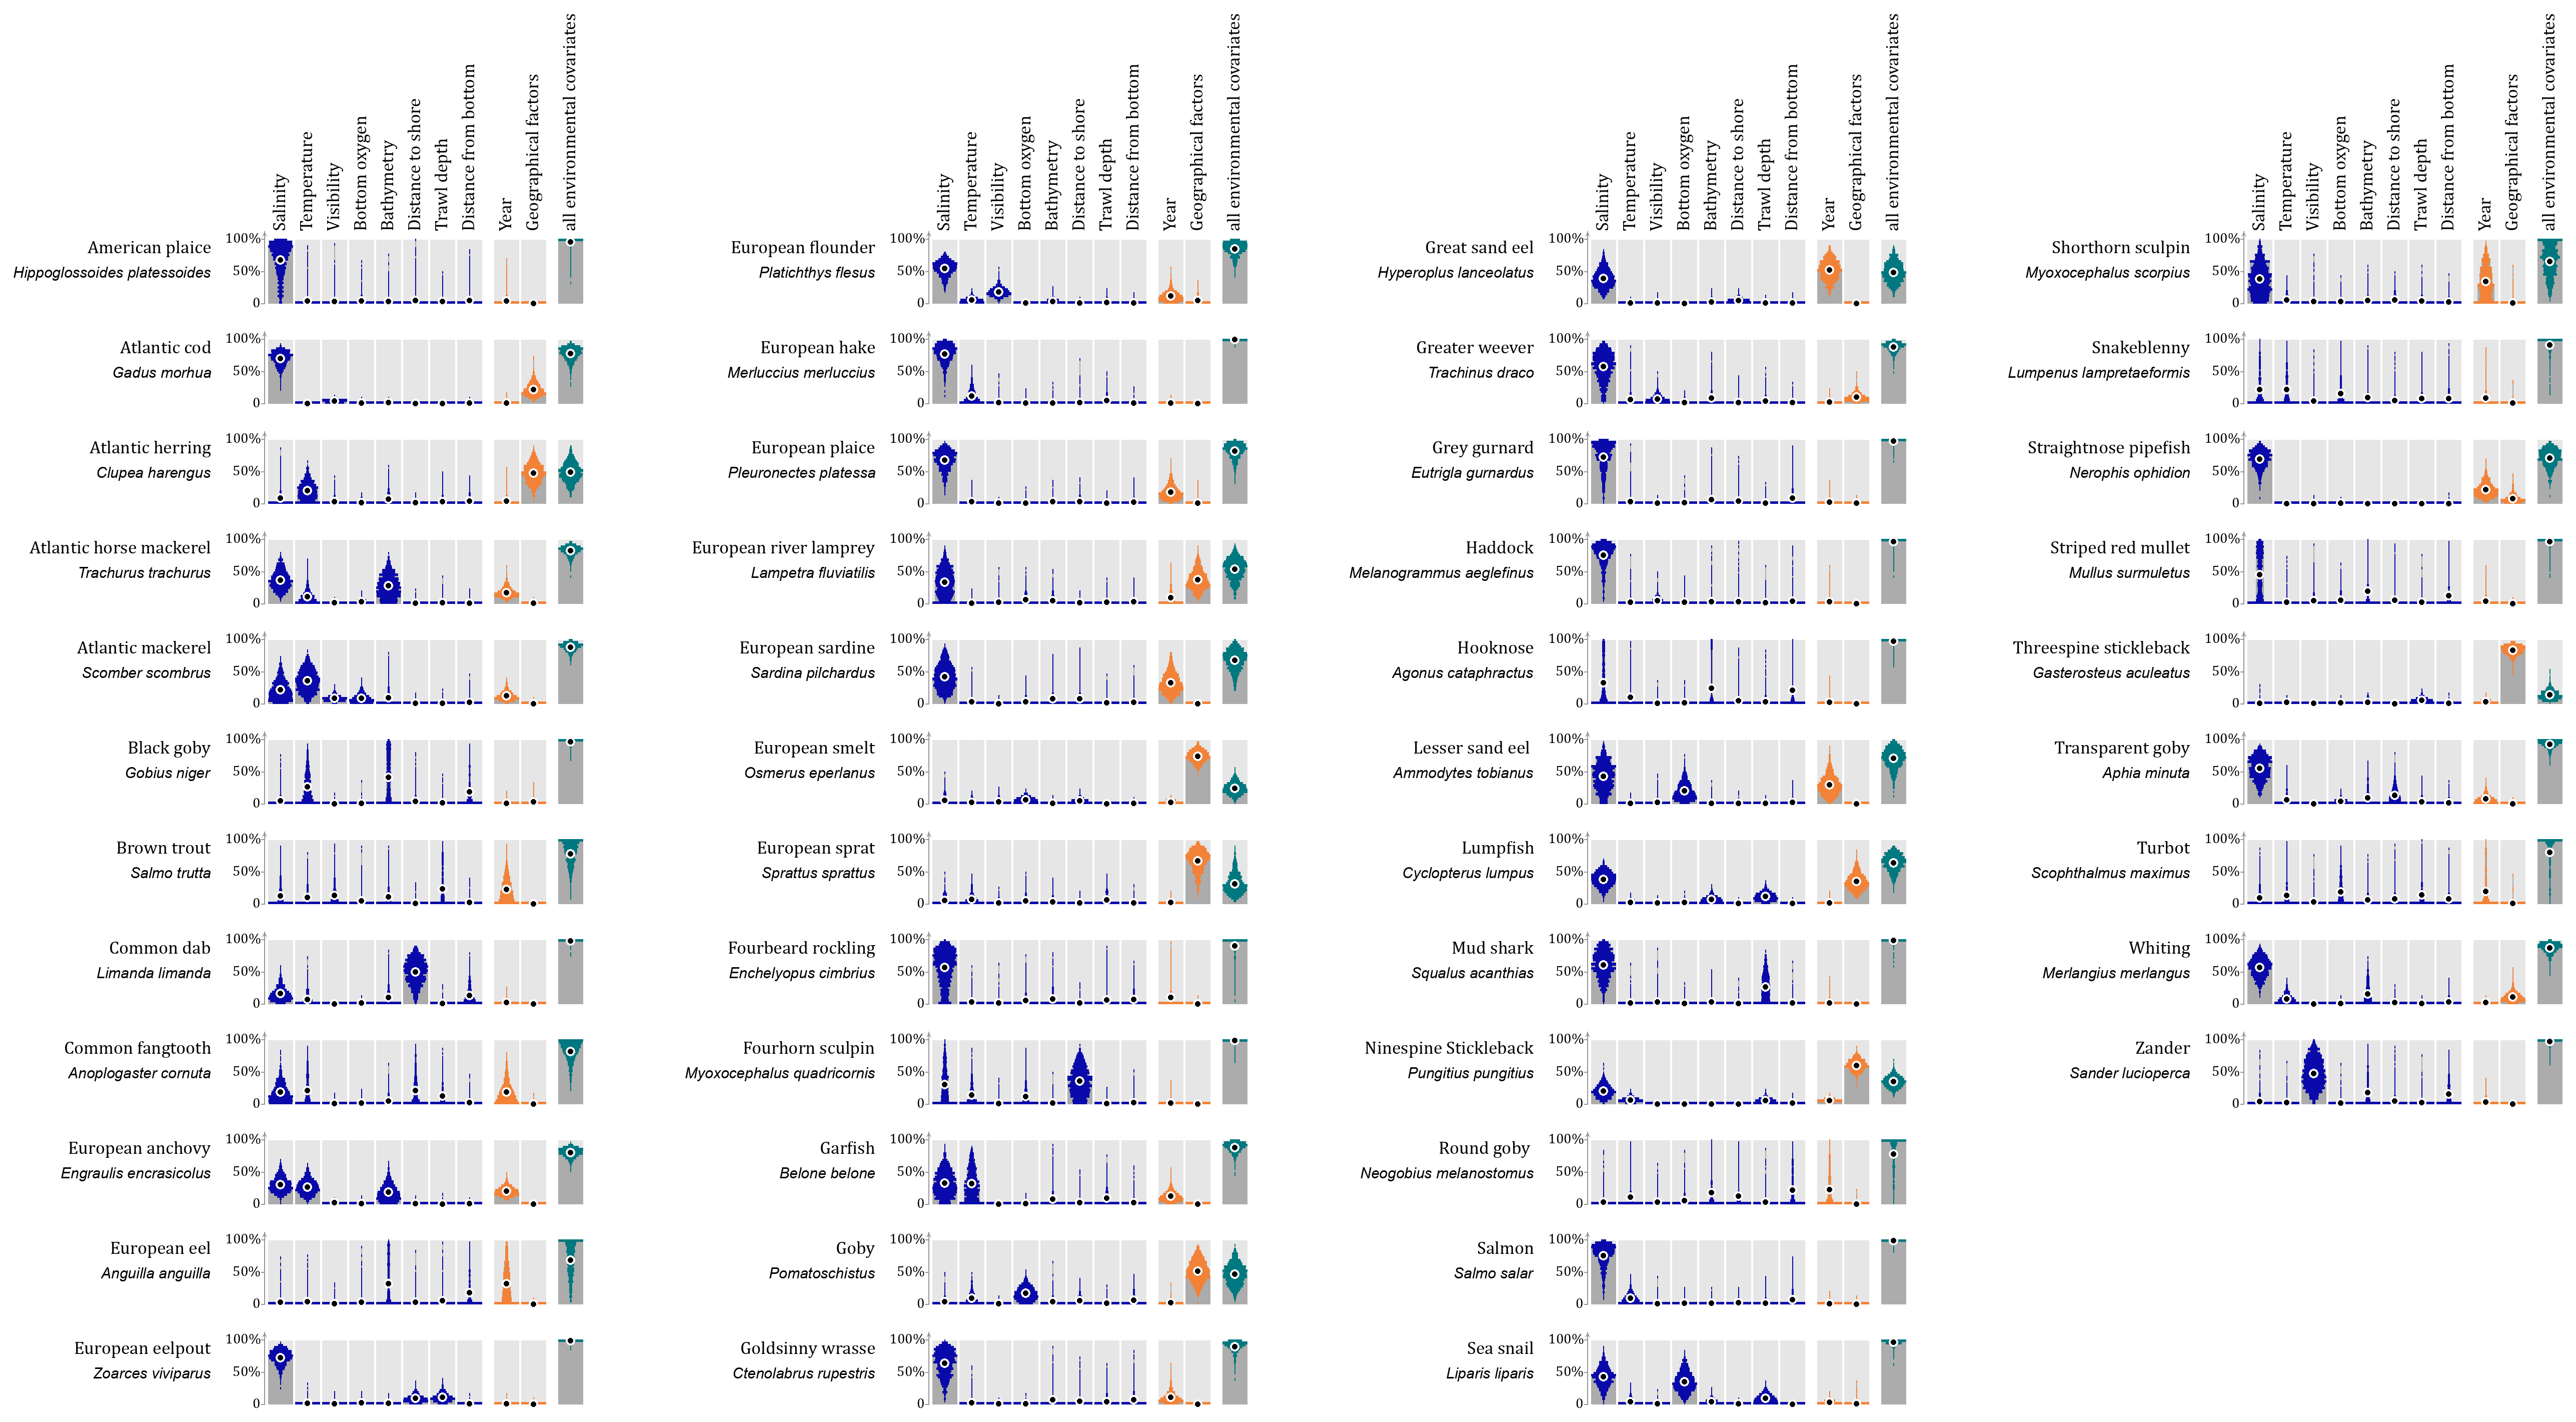

In [5]:



def lineplot(s, par, i, j):
    
    title = {
        'depth': 'Bathymetry',
        'dts': 'Distance to shore',
        'dfb': 'Distance from bottom',
        'td': 'Trawl depth',
        'sd': 'Distance from surface ',
        'salt': 'Salinity',
        'temp': 'Temperature',
        'turb': 'Visibility',
        'oxyg': 'Bottom oxygen',
        'year': 'Year',

        'geo': 'Geographical factors',
        
        #'a_env': 'all environmental covariates',
        'a_env': 'all environmental covariates',
        'a_rand': 'all random effects'
    }[par]

    P = artist.Panel(50, ('%', 0, 1, 130), '<<')
    if j == 0:
        P.left = True
        P.left = (0, 0.5, 1)
    else:
        P.left = False
        
    if i == 0:
        P.text(0, 1, '  '+title, pos='^.')
        

    P.rect([-1, 1], [0, 1], col='___k')
    P.lines([-1, 1], [1, 1], col='w')

    subset = VP[VP.Species == s.name]
    tot = sum(subset[par] for par in 'salt temp turb oxyg  depth dts td dfb   year  geo'.split())
    if par == 'a_env':
        q = sum(subset[par] for par in 'salt temp turb oxyg  depth dts td dfb '.split())
    elif par == 'a_rand':
        q = subset.year + subset.geo
    else:
        q = subset[par]
    q = q / tot
    
    if par in 'year geo':
        col = 'o'
    elif par == 'a_env':
        col = '-c'
    else:
        col = 'b'
        
    N = 30
    H = array([(q > k/N).sum() for k in range(3*N+1)])
    H = H[:-1] - H[1:]
    H = H/max(H)
    for k in range(3*N):
        if H[k] > 0:
            P.rect([-H[k], H[k]], [k/N, (k+1)/N], col=col)
            P.rect([-H[k], H[k]], [0, k/N], col='-w', z=-1)
    
    m = q.mean()
    P.circle(0, m, r=9, col='w')
    P.circle(0, m, r=5, col='k')

    return P


def plot_for_species(s, i):
    PP = artist.Panel()
    PP.text(0, 0, s.latin, pos='<.', font=(30, 'ariali.ttf')).move(0, 60)
    PP.text(0, 0, s.name, pos='<.').move(0, 110)
    PP += 40
    for j, cov in enumerate(' salt temp turb oxyg  depth dts td dfb   year  geo a_env '.split()):
        if cov in 'a_env year':
            PP += 20
        PP = PP +(-50) + lineplot(s, cov, i, j)
    return PP
                
    
def plot_for_clisters(CLUSTERS):
    PPP = artist.Panel()
    i = j = 0
    for CL in CLUSTERS:
        top = True
        for short in CL: 
            s = SL[short]
            PP = plot_for_species(s, i)

            i += 1
            PPP *= PP.move(0, -200*i)
            top = False

        i += 1
    return PPP

    
def plot_for_several_species(CL):
    PPP = artist.Panel()
    for i, s in enumerate(CL): 
        s = SL[s]
        PP = plot_for_species(s, i)
        PPP *= PP.move(0, -200*i)
    return PPP
    
    
#PPP = (plot_for_clisters(CLUSTERS[:2]) + 200 +
#       plot_for_clisters(CLUSTERS[2:4]) + 200 +
#       plot_for_clisters(CLUSTERS[4:7]) + 200 +
#       plot_for_clisters(CLUSTERS[7:]))
 
SSL = [s.short for s in sorted(SL, key=lambda s: s.name)]
    
PPP = (
       plot_for_several_species(SSL[:12]) + 150 +
       plot_for_several_species(SSL[12:24]) + 150 +
       plot_for_several_species(SSL[24:36]) + 150 +
       plot_for_several_species(SSL[36:])
      )

PPP.save(f'results_appendix/all_responses_VP.png')
PPP.show()

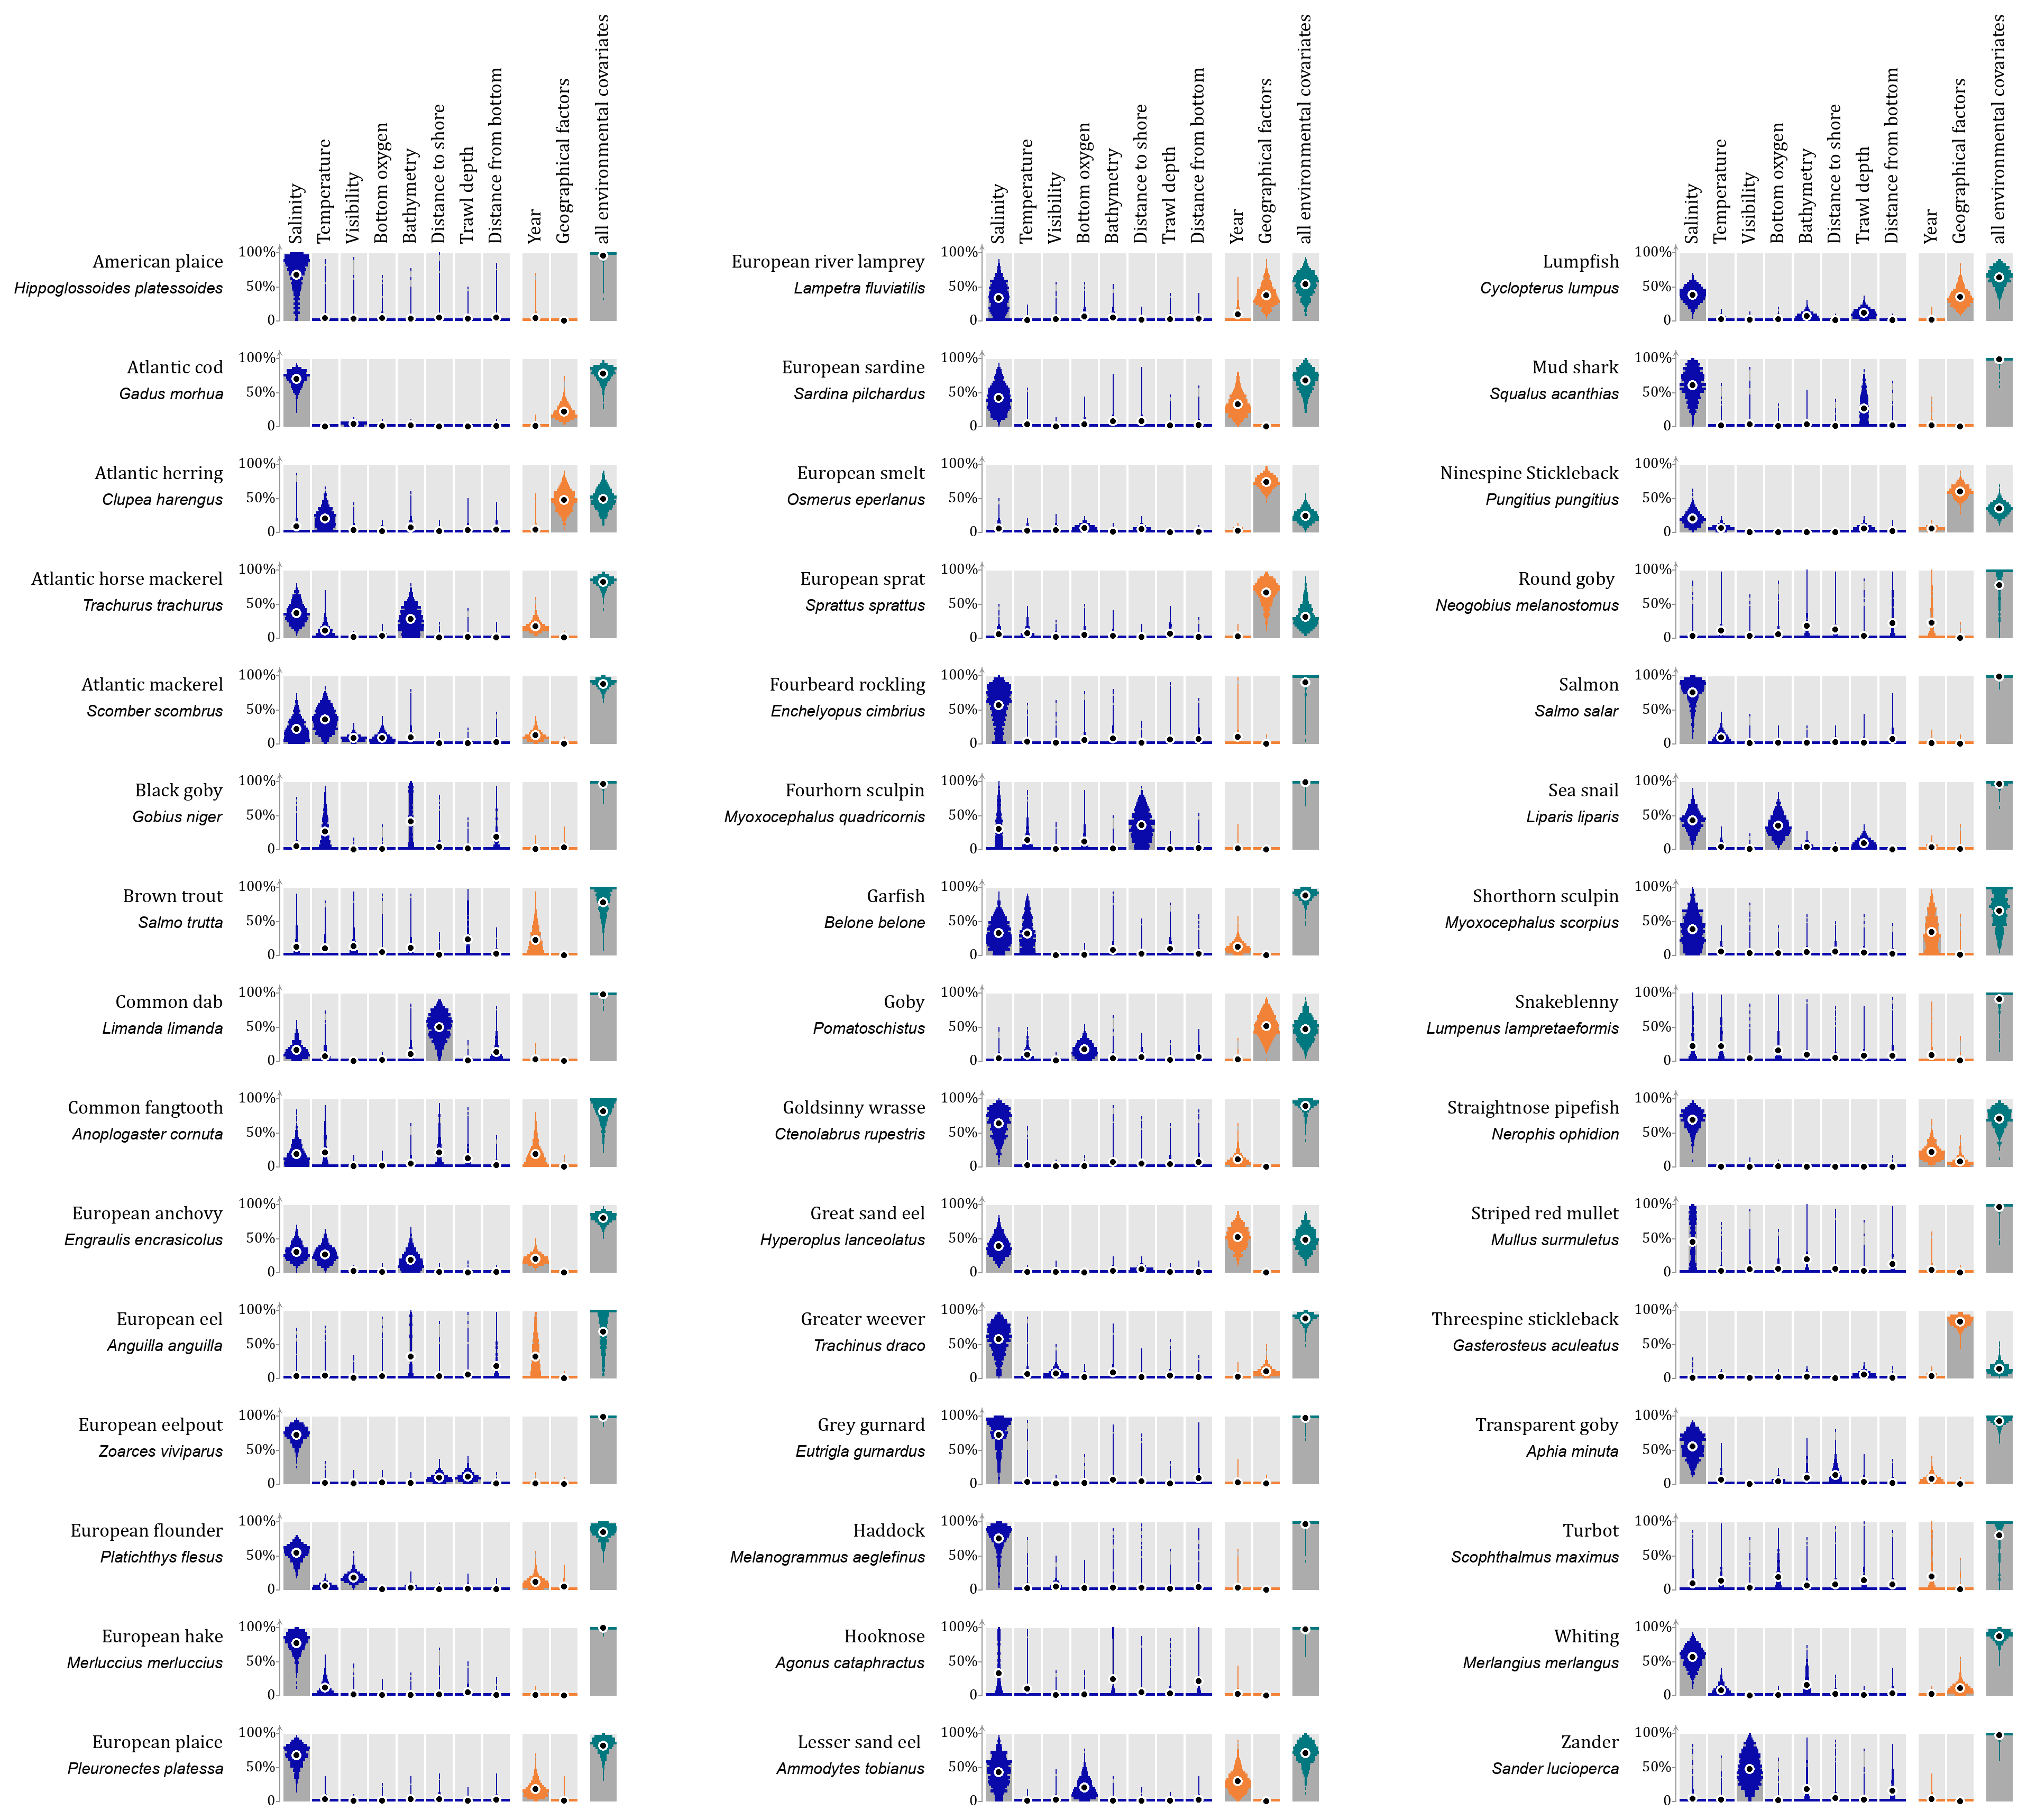

In [6]:
PPP = (
       plot_for_several_species(SSL[:15]) + 150 +
       plot_for_several_species(SSL[15:30]) + 150 +
       plot_for_several_species(SSL[30:])
      )

PPP.save(f'results_appendix/all_responses_VP.png')
PPP.show()

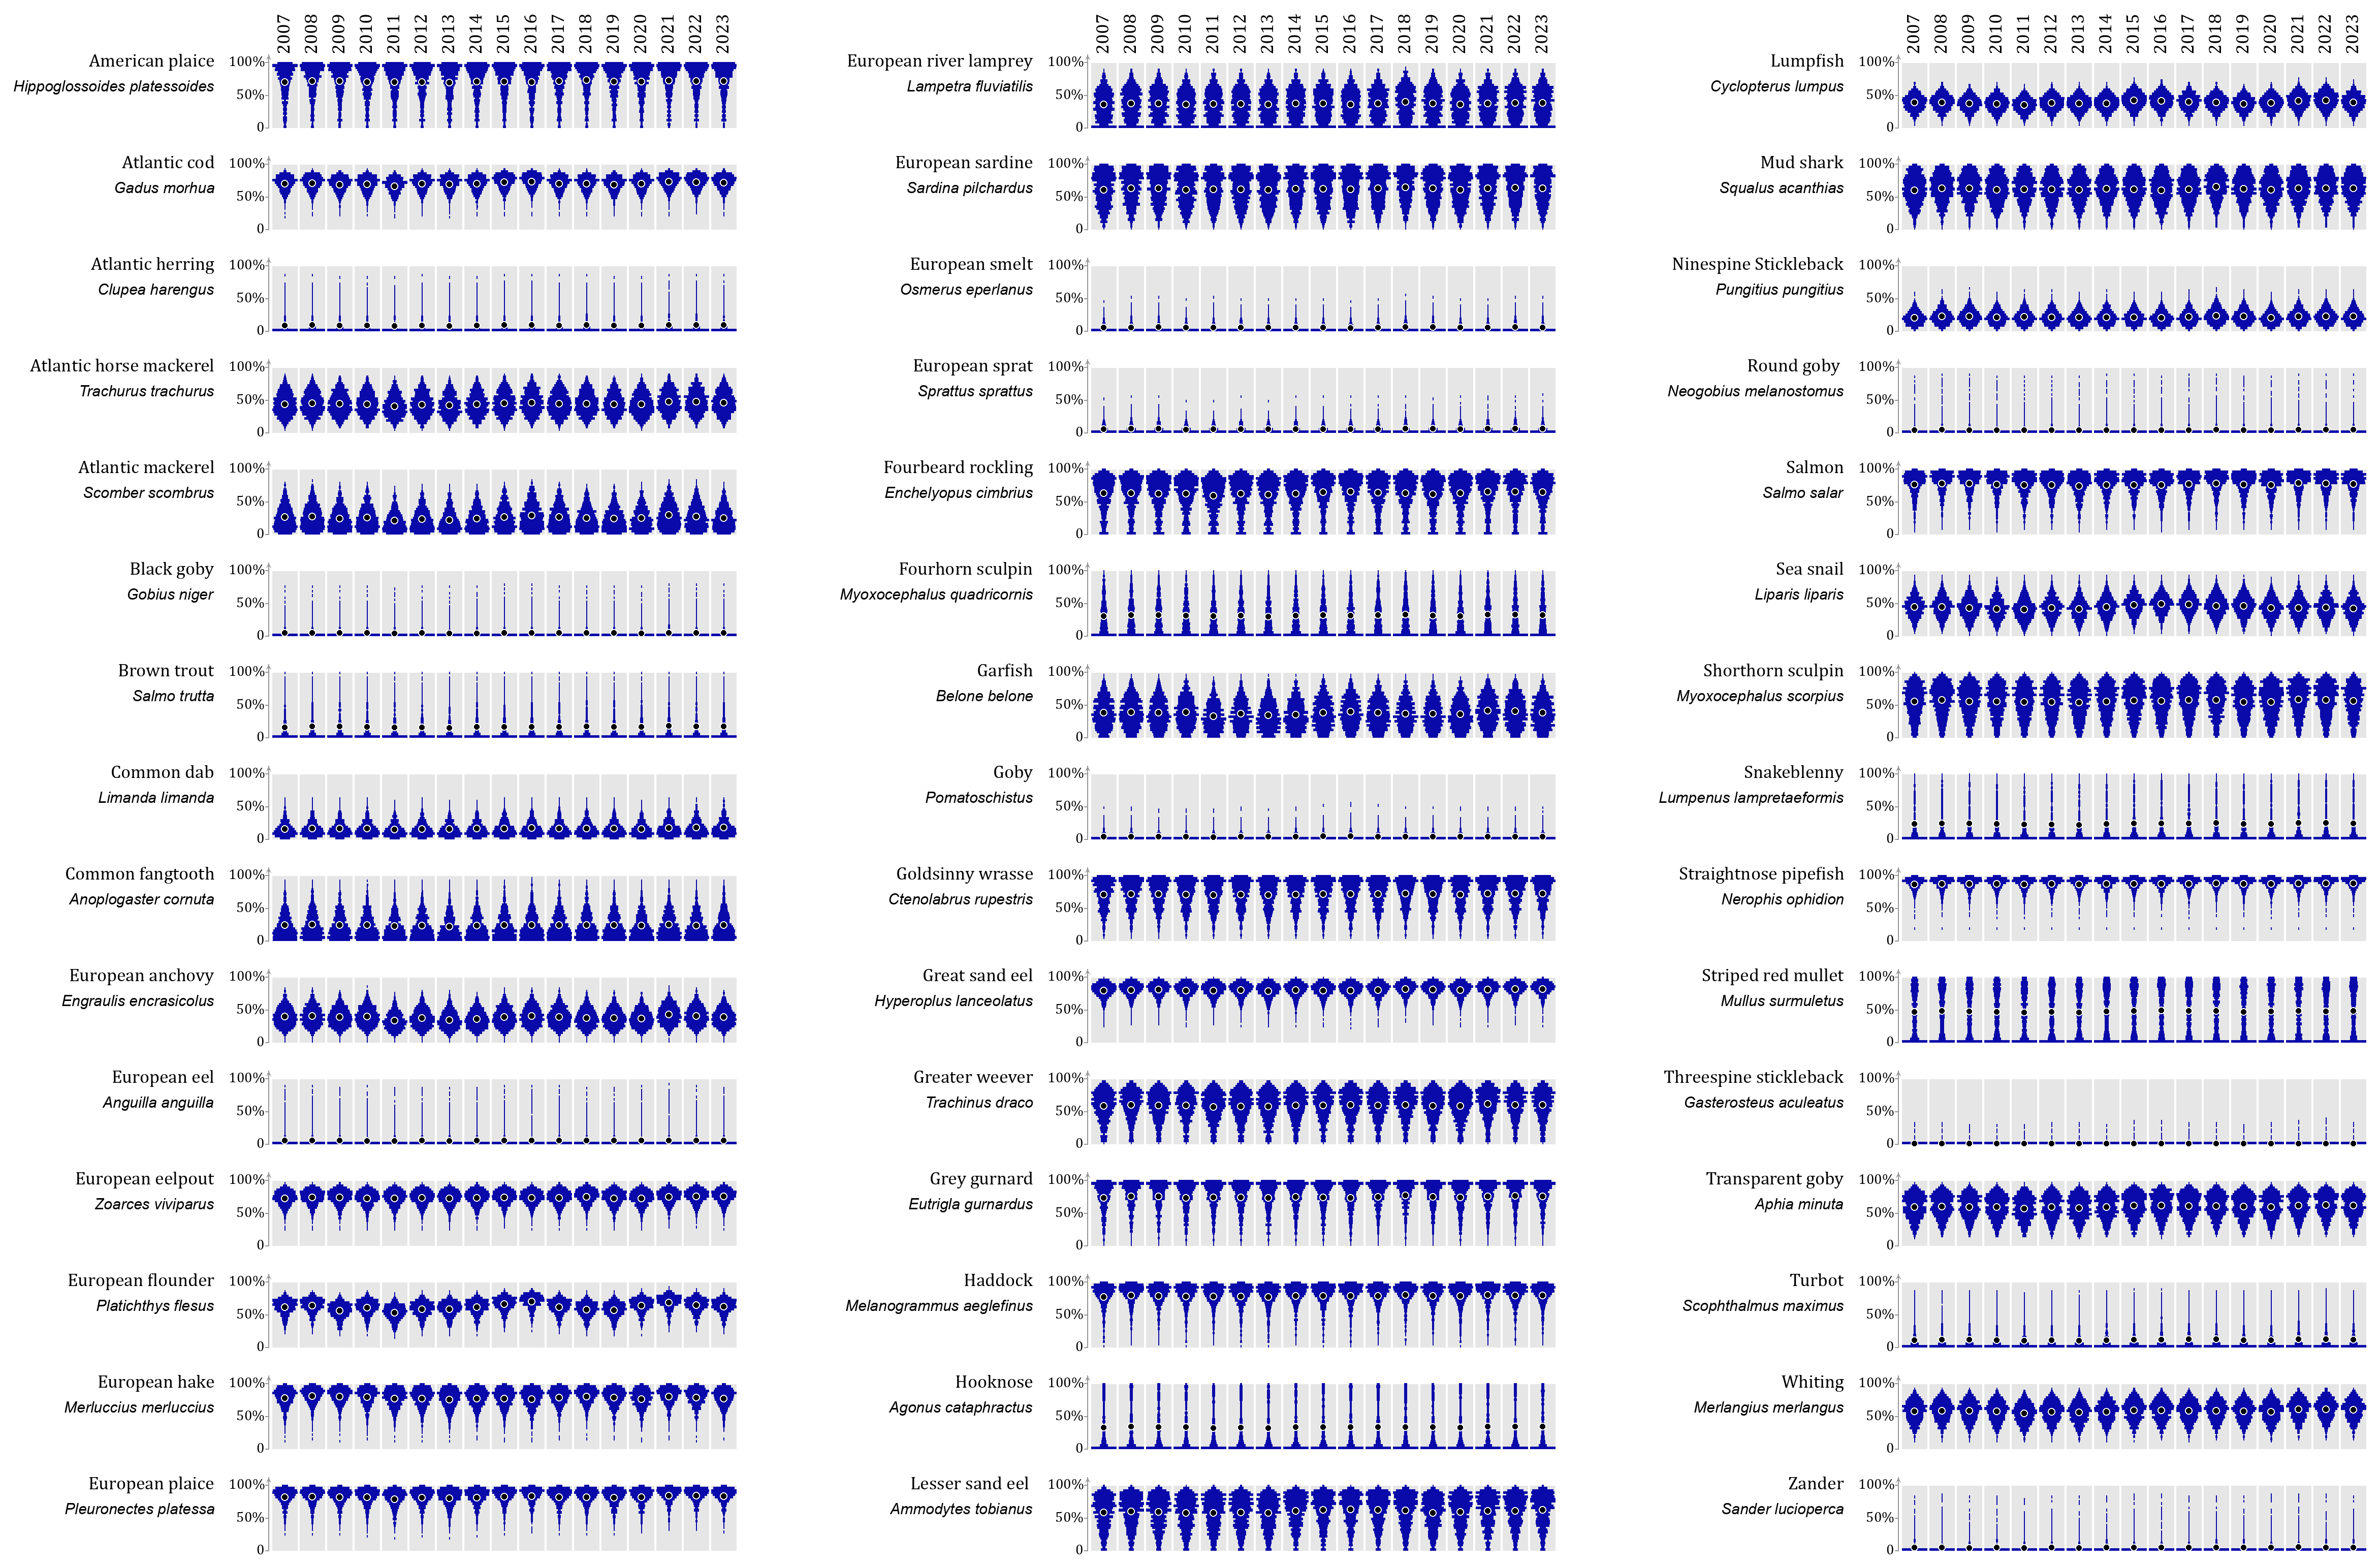

In [7]:
def lineplot(s,  i, y):

    P = artist.Panel(50, ('%', 0, 1, 130), '<<')
    if y == 0:
        P.left = True
        P.left = (0, 1, 0.5)
    else:
        P.left = False
        
    if i == 0:
        P.text(0, 1, '  '+str(y+2007), pos='^.')
        

    P.rect([-1, 1], [0, 1], col='___k')
    P.lines([-1, 1], [1, 1], col='w')

    subset = VP[VP.Species == s.name]
    tot = sum(subset[par] for par in f'salt_{y} temp_{y} turb_{y} oxyg_{y}  depth dts td dfb   geo'.split())
    q = subset['salt_'+str(y)]
    q /= tot
    col = 'b'
        
    N = 30
    H = array([(q > k/N).sum() for k in range(3*N+1)])
    H = H[:-1] - H[1:]
    H = H/max(H)
    for k in range(3*N):
        if H[k] > 0:
            P.rect([-H[k], H[k]], [k/N, (k+1)/N], col=col)
    
    m = q.mean()
    P.circle(0, m, r=7, col='w')
    P.circle(0, m, r=5, col='k')

    return P


def plot_for_species(s, i):
    PP = artist.Panel()
    PP.text(0, 0, s.latin, pos='<.', font=(30, 'ariali.ttf')).move(0, 80)
    PP.text(0, 0, s.name, pos='<.').move(0, 130)
    PP += 40
    for y in range(17):
        PP = PP +(-50) + lineplot(s, i, y)
    return PP
                
    
PPP = (
       plot_for_several_species(SSL[:15]) + 150 +
       plot_for_several_species(SSL[15:30]) + 150 +
       plot_for_several_species(SSL[30:])
      )

PPP.save(f'results_appendix/all_responses_VP_salt.png')
PPP.show()

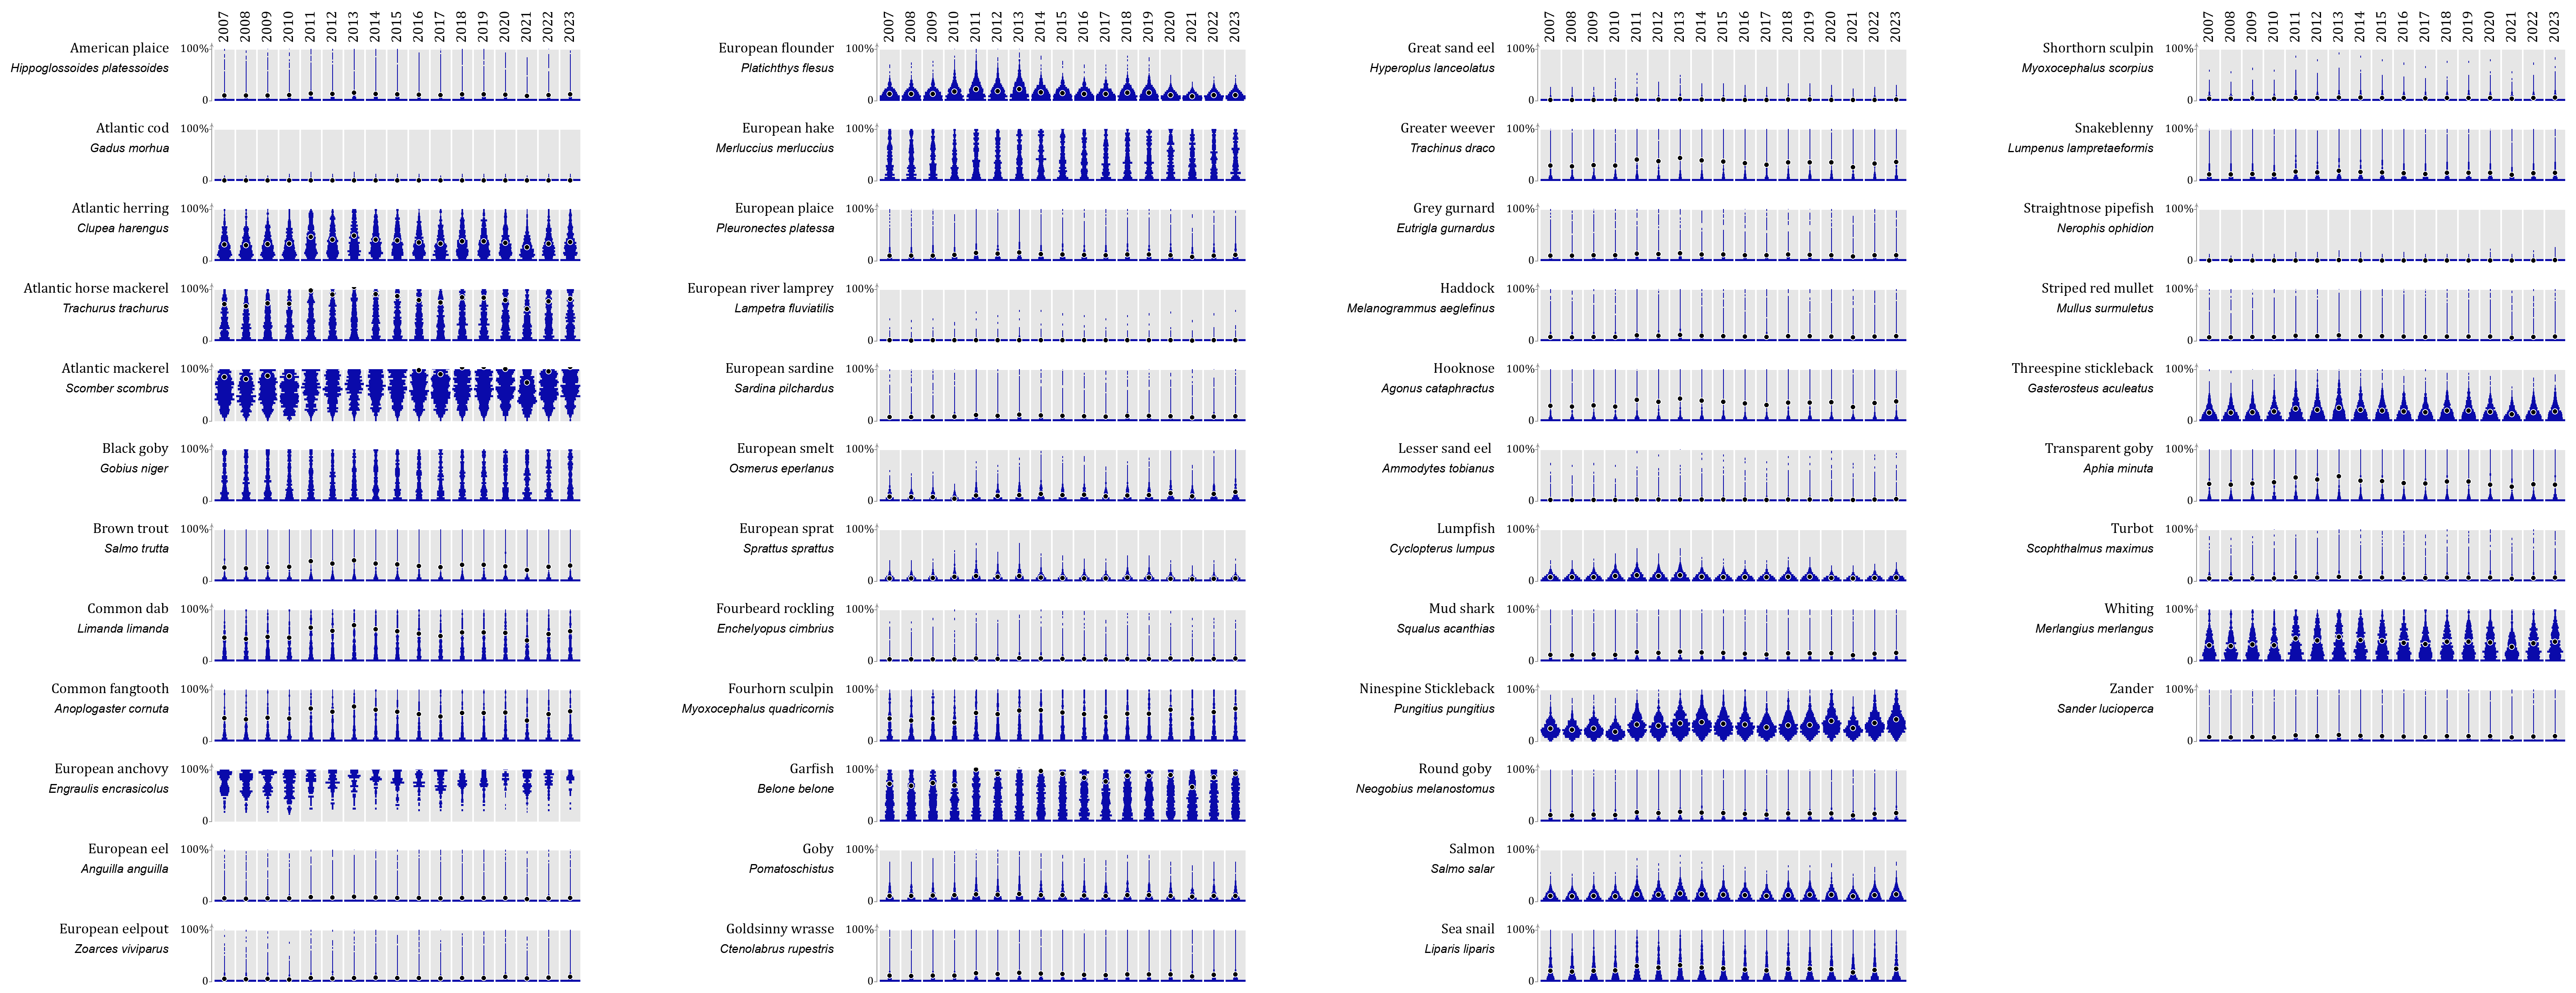

In [8]:
def lineplot(s,  i, y):

    P = artist.Panel(50, ('%', 0, 1, 130), '<<')
    if y == 0:
        P.left = True
        P.left = (0, 1, 2)
    else:
        P.left = False
        
    if i == 0:
        P.text(0, 1, '  '+str(y+2007), pos='^.')
        

    P.rect([-1, 1], [0, 3], col='___k')
    P.lines([-1, 1], [1, 1], col='w')

    subset = VP[VP.Species == s.name]
    q = subset['temp_'+str(y)]
    col = 'b'
        
    N = 30
    H = array([(q > k/N).sum() for k in range(3*N+1)])
    H = H[:-1] - H[1:]
    H = H/max(H)
    for k in range(3*N):
        if H[k] > 0:
            P.rect([-H[k], H[k]], [k/N, (k+1)/N], col=col)
    
    m = q.mean()
    P.circle(0, m, r=7, col='w')
    P.circle(0, m, r=5, col='k')

    return P


def plot_for_species(s, i):
    PP = artist.Panel()
    PP.text(0, 0, s.latin, pos='<.', font=(30, 'ariali.ttf')).move(0, 80)
    PP.text(0, 0, s.name, pos='<.').move(0, 130)
    PP += 40
    for y in range(17):
        PP = PP +(-50) + lineplot(s, i, y)
    return PP
                
    
PPP = (
       plot_for_several_species(SSL[:12]) + 200 +
       plot_for_several_species(SSL[12:24]) + 200 +
       plot_for_several_species(SSL[24:36]) + 200 +
       plot_for_several_species(SSL[36:])
      )

PPP.save(f'results_appendix/all_responses_VP_temp.png')
PPP.show()